# Loading required libraries

In [1]:
library(ggplot2)
library(patchwork)
library(broom)
library(scales)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(showtext)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reve

# Figures and Files Setup

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_6"

# Color palettes

In [3]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)

# Load the required data

In [4]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Abdomen")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Abdomen"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

In [6]:
#read cell type percentages per patient
celltype_percentage_patient <- read.csv(file.path(data_dir, "celltype_percentage_patient.csv"))
cellparent_percentage_patient <- read.csv(file.path(data_dir, "cellparent_percentage_patient.csv"))

In [7]:
#niches df 
niches_df <- read.csv(file.path(data_dir, "niches_df.csv"))

In [8]:
interaction_df <- read.csv(file.path(data_dir, "myeloid_t_interactions.csv"))
mdscs_interaction <- interaction_df %>%
filter(celltype_A == "MDSCs")

# B

### for plot B, refer to the COZI folder

# C

In [14]:
plot_highlight <- function(df, highlight_levels, title = NULL,
                           bg_color = "#D9D9D9", bg_alpha = 1,
                           pt_size_bg = 1.5, pt_size_fg = 1.5) {

  df_bg <- df %>% dplyr::filter(!cell_category %in% highlight_levels)
  df_fg <- df %>% dplyr::filter(cell_category %in% highlight_levels)

  # palette restricted to highlighted cells (keeps your exact colors)
  pal_hl <- full_palette[highlight_levels]
  pal_hl <- pal_hl[!is.na(pal_hl)]  # safety if some names not present

  ggplot() +
    geom_point(
      data = df_bg,
      aes(x = `Cell Center X`, y = `Cell Center Y`),
      color = bg_color,
      alpha = bg_alpha,
      size = pt_size_bg
    ) +
    geom_point(
      data = df_fg,
      aes(x = `Cell Center X`, y = `Cell Center Y`, color = cell_category),
      alpha = 0.95,
      size = pt_size_fg
    ) +
    scale_color_manual(
      values = pal_hl,
      breaks = highlight_levels,   # <- legend entries limited to highlighted
      drop = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "none"
    ) +
    ggtitle(title) +
    scale_y_reverse()
}  


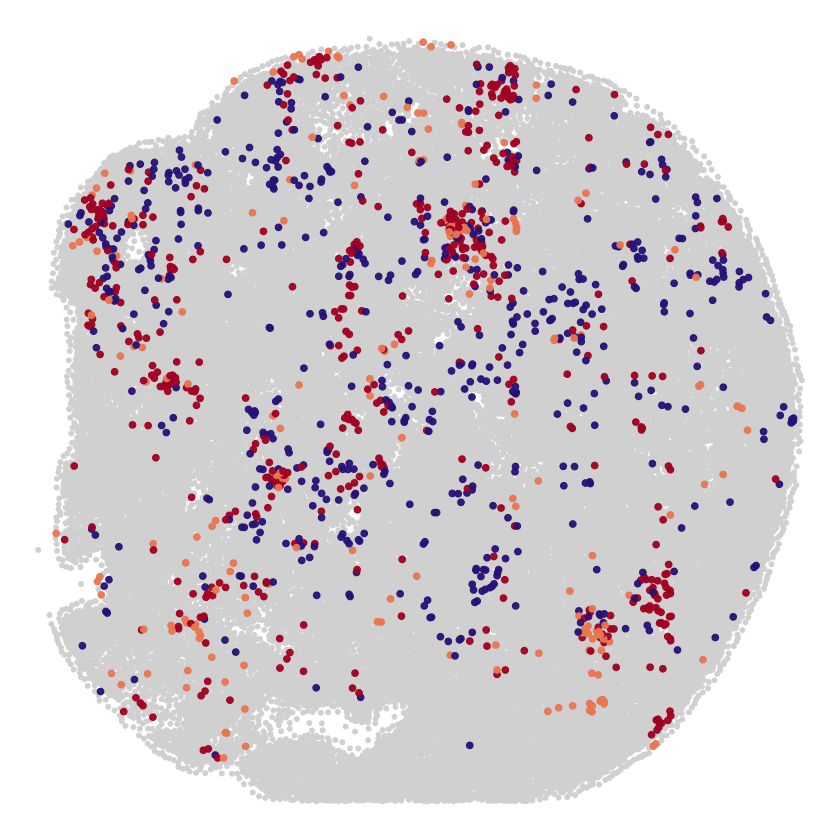

In [15]:
exp <- "NUT_5_ROI11"
df <- celltype_metadata %>%
  filter(patient_exp == exp)

p <- plot_highlight(
  df,
  pt_size_bg = 1, pt_size_fg = 1.5,
  highlight_levels = c("MDSCs", "CD8+ T cells", "CD4+ T cells"))
p

ggsave(filename = file.path(results_dir, "NMC_5_ROI11_mdscscd8.pdf"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

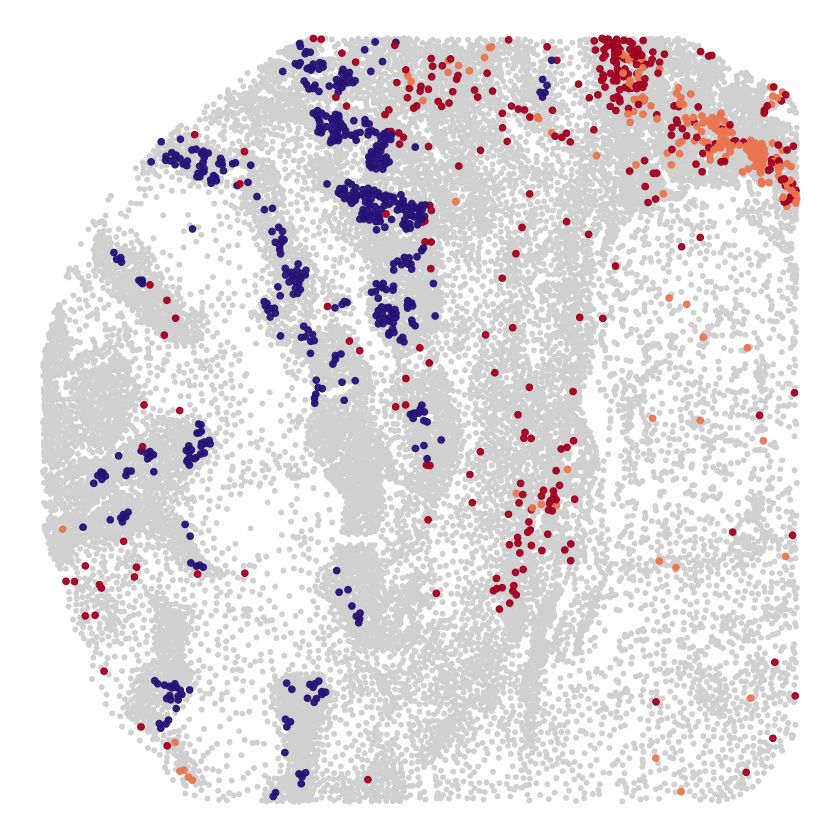

In [16]:
exp <- "NUT_7_ROI13"
df <- celltype_metadata %>%
  filter(patient_exp == exp)

p <- plot_highlight(
  df,
  pt_size_bg = 1, pt_size_fg = 1.5,
  highlight_levels = c("MDSCs", "CD8+ T cells", "CD4+ T cells"))
p

ggsave(filename = file.path(results_dir, "NMC_7_ROI13_mdscscd8.pdf"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

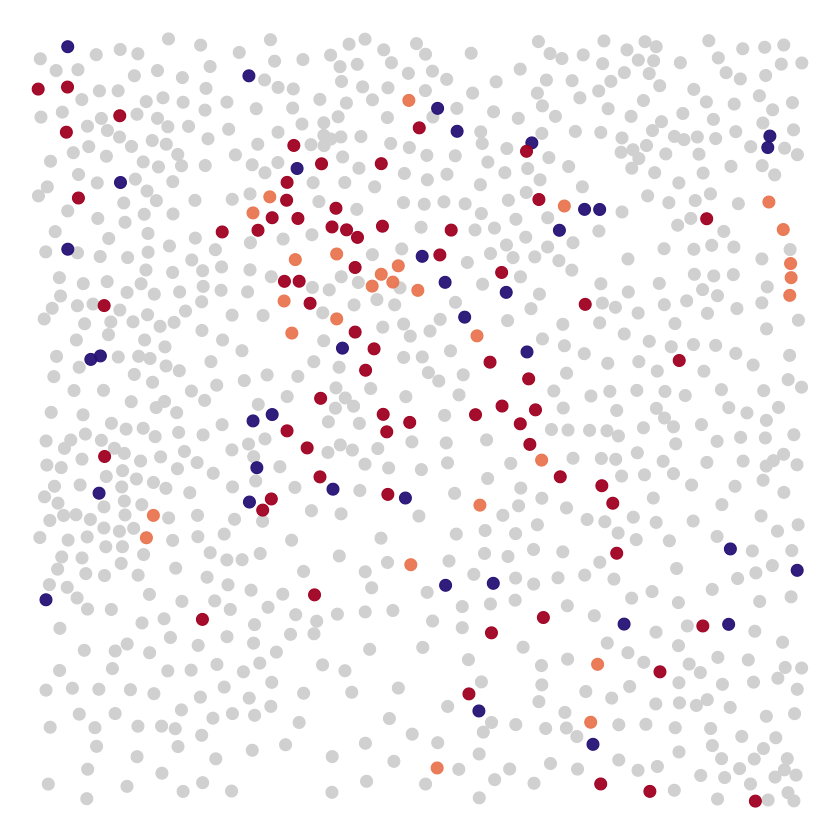

In [17]:
exp <- "NUT_5_ROI11"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 7500 & `Cell Center X` <= 9500, 
    `Cell Center Y` >= 3250 & `Cell Center Y` <= 5250)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells", "CD4+ T cells"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_1", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

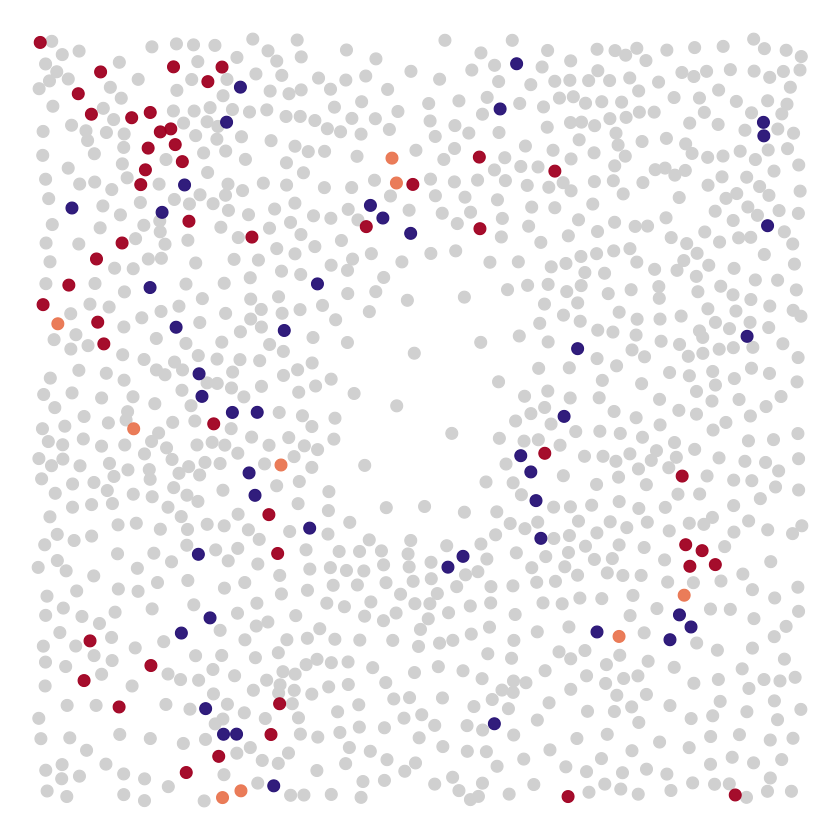

In [18]:
exp <- "NUT_5_ROI11"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 950 & `Cell Center X` <= 2950, 
    `Cell Center Y` >= 3300 & `Cell Center Y` <= 5300)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells", "CD4+ T cells"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_2", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

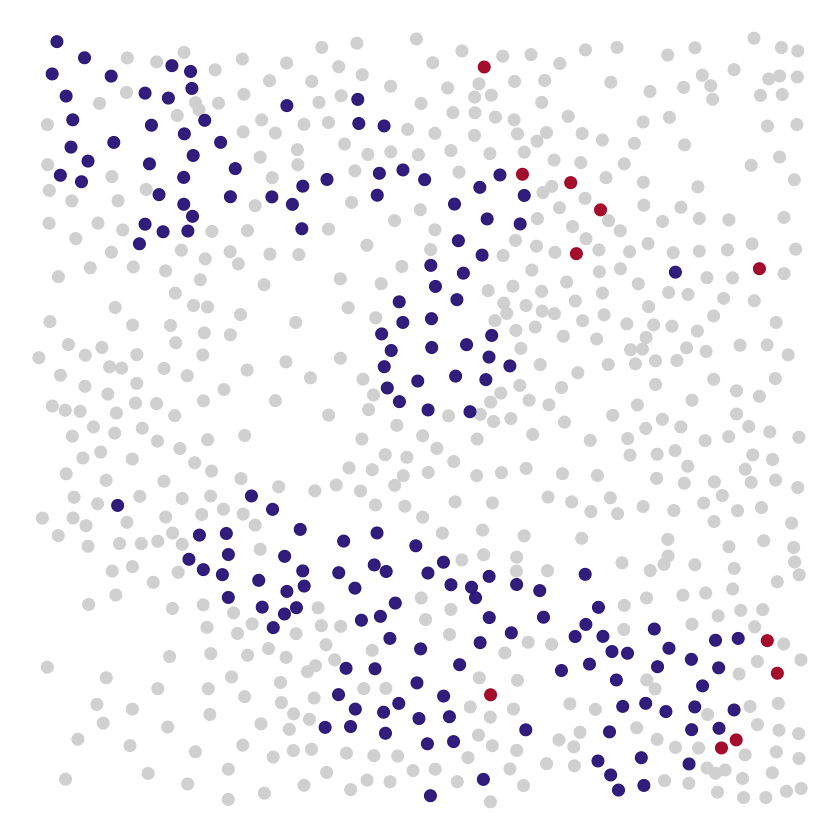

In [19]:
exp <- "NUT_7_ROI13"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 4500 & `Cell Center X` <= 6500, 
    `Cell Center Y` >= 1200 & `Cell Center Y` <= 3200)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells", "CD4+ T cells"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_1", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

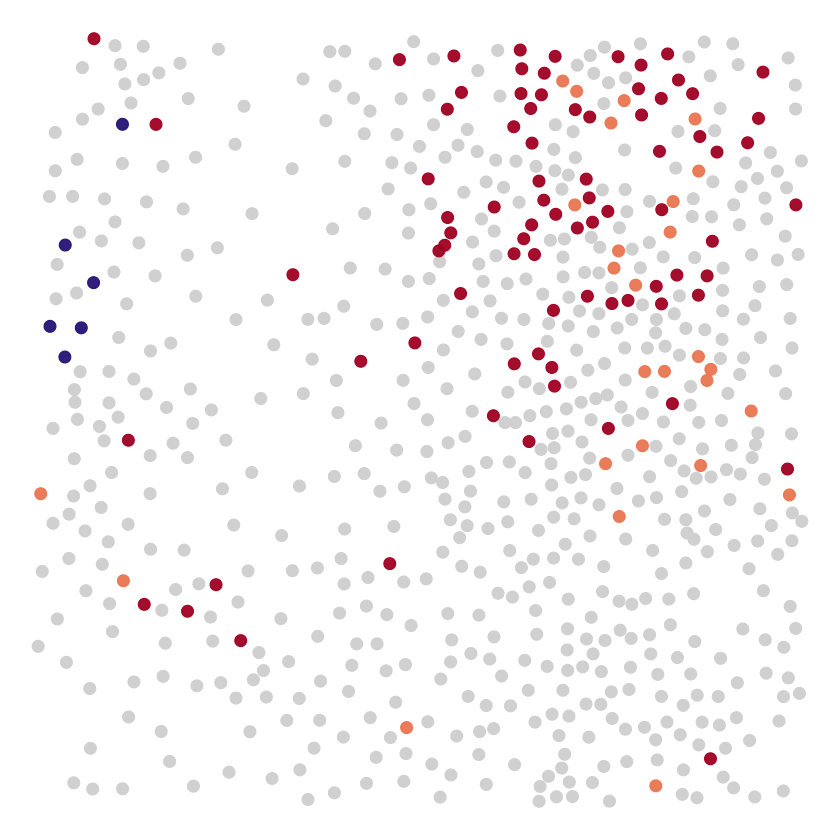

In [20]:
exp <- "NUT_7_ROI13"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 8200 & `Cell Center X` <= 10200, 
    `Cell Center Y` >= 150 & `Cell Center Y` <= 2150)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells", "CD4+ T cells"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_2", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

## NEW PATIENTS

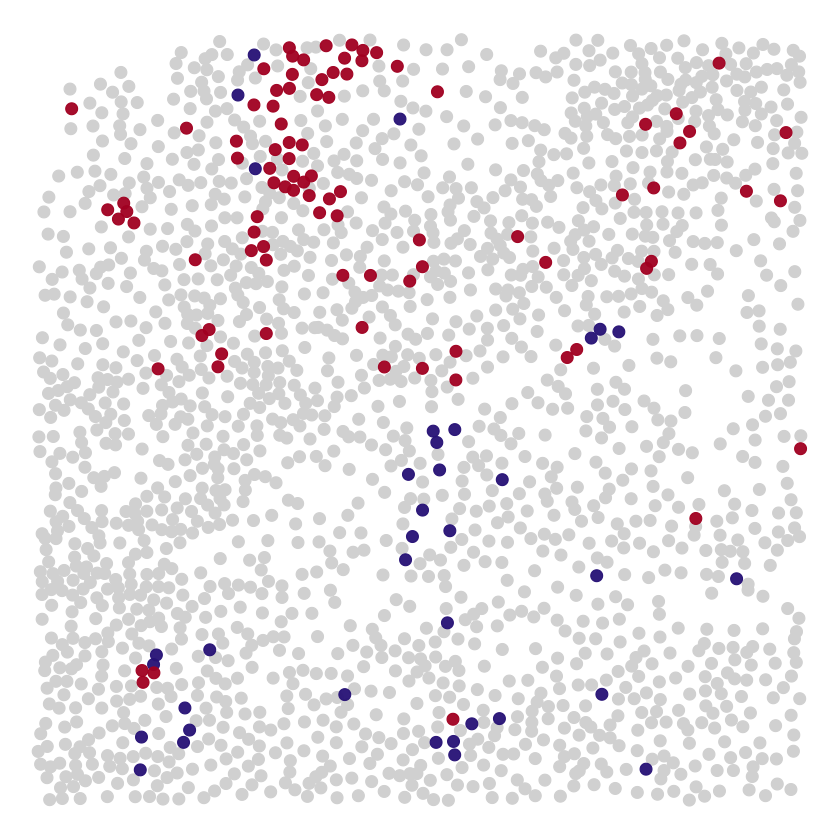

In [14]:
exp <- "NUT_2_ROI1"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 4000 & `Cell Center X` <= 6000, 
    `Cell Center Y` >= 900 & `Cell Center Y` <= 2900)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_1", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

# D

In [11]:
#calculate proportions of mdscs for NUT_5 and NUT_7
mdscs_percentage <- celltype_metadata %>%
  filter(patient_ID %in% c("NUT_5", "NUT_7")) %>%
  group_by(patient_ID, patient_exp, cell_category) %>%
    summarise(count = n()) %>%
    ungroup() %>%
    group_by(patient_ID, patient_exp) %>%
    mutate(proportion = count / sum(count)) %>%
    #calculate mean per patient
    group_by(patient_ID, cell_category) %>%
    summarise(mean_proportion = mean(proportion)) %>%
    ungroup() %>%
    filter(cell_category %in% c("MDSCs", "CD8+ T cells", "CD4+ T cells")) %>%
    mutate(percentage = mean_proportion * 100)
mdscs_percentage

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID, patient_exp, and
  cell_category.
ℹ Output is grouped by patient_ID and patient_exp.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, patient_exp, cell_category))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


patient_ID,cell_category,mean_proportion,percentage
<fct>,<chr>,<dbl>,<dbl>
NUT_5,CD4+ T cells,0.012459889,1.2459889
NUT_5,CD8+ T cells,0.015894046,1.5894046
NUT_5,MDSCs,0.018010694,1.8010694
NUT_7,CD4+ T cells,0.009451146,0.9451146
NUT_7,CD8+ T cells,0.010812750,1.0812750
NUT_7,MDSCs,0.022570183,2.2570183


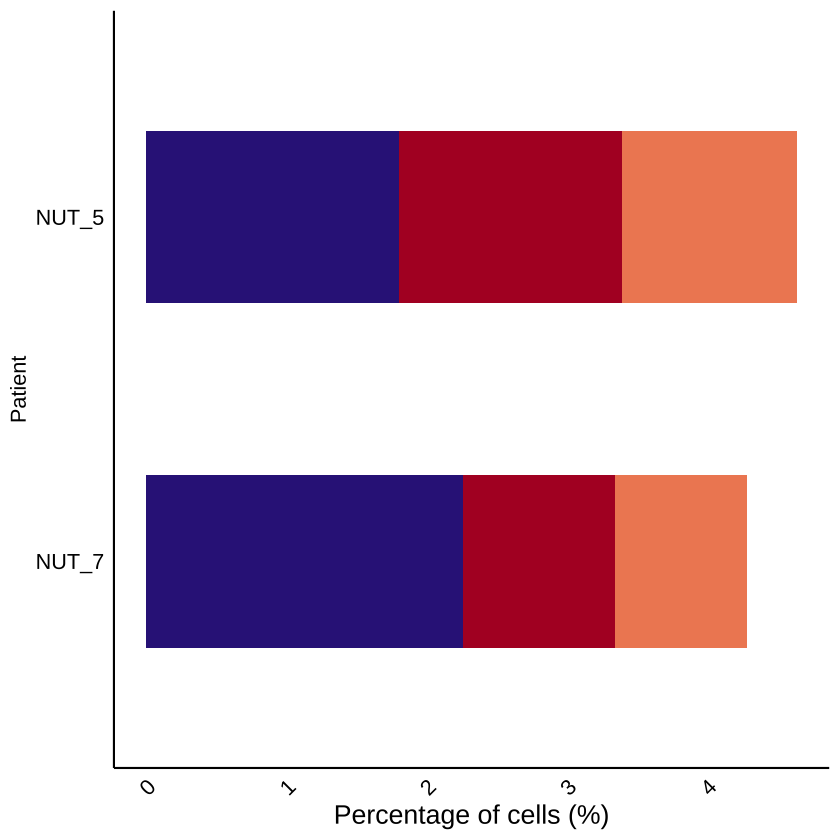

In [12]:
#barplot for comparison 
comparison_barplot <- ggplot(
  mdscs_percentage,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.5) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank())

comparison_barplot

ggsave(
  filename = file.path(results_dir, "patientmdscscd8_composition_barplot.pdf"),
  plot = comparison_barplot,
  width = 4,
  height = 3,
  dpi = 300,
  bg = "white"
)

# E

In [114]:
interaction_df %>%
filter(patient_ID == "NUT_1")

patient_ID,cell_pair,zscore,zscore_normalized,cond_percent,celltype_A,celltype_B
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
NUT_1,MDSCs-CD8+ T cells,1.68711219,0.019265543,9.5959596,MDSCs,CD8+ T cells
NUT_1,CD8+ T cells-MDSCs,1.10413530,0.008650556,9.2500000,CD8+ T cells,MDSCs
NUT_1,MDSCs-CD4+ T cells,0.03984324,0.001021897,2.8457653,MDSCs,CD4+ T cells
NUT_1,CD4+ T cells-MDSCs,-0.02976645,0.000561398,5.5053191,CD4+ T cells,MDSCs
NUT_1,M2 macrophages-CD8+ T cells,0.74832276,0.009078271,6.7230733,M2 macrophages,CD8+ T cells
NUT_1,CD8+ T cells-M2 macrophages,0.51111612,0.007189310,19.9166667,CD8+ T cells,M2 macrophages
NUT_1,M2 macrophages-CD4+ T cells,1.45932300,0.015245495,5.5094407,M2 macrophages,CD4+ T cells
NUT_1,CD4+ T cells-M2 macrophages,3.00033396,0.028570077,27.9521277,CD4+ T cells,M2 macrophages
NUT_1,Granulocytes-CD8+ T cells,NA,NA,10.0000000,Granulocytes,CD8+ T cells


In [144]:
mdscs_interaction_cd8

patient_ID,MDSCs-CD8+ T cells,CD8+ T cells-MDSCs,zscore_diff,tumor_site,survival_time_months,event,is_lung
<chr>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>
NUT_9,22.9057743,-0.27015092,23.1759252,Lung,2,1,Lung
NUT_2,5.2955410,-0.39937320,5.6949142,Lung,3,1,Lung
NUT_4,8.7383982,4.51342525,4.2249730,Lung,4,1,Lung
NUT_8,7.6074975,3.61209064,3.9954069,Lung,4,1,Lung
NUT_15,1.1842896,0.05563428,1.1286553,Lung,5,1,Lung
NUT_13,-0.6318794,-0.63187935,0.0000000,Lung,6,1,Lung
NUT_6,NA,NA,NA,Lung,7,1,Lung
NUT_7,0.4043368,6.35560173,-5.9512649,Lung,10,1,Lung
NUT_5,11.8054416,5.42934729,6.3760943,Head and Neck,9,1,Non-Lung


In [148]:
mdscs_interaction_cd8 <- mdscs_interaction_cd8 %>%
select(patient_ID, zscore_diff, survival_time_months, event, is_lung)

# ---- prep: drop NUT_6 (NA score), z-score the covariate ----
model_df <- mdscs_interaction_cd8 %>%
  filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
  mutate(MDSC_CD8_z = as.numeric(scale(`zscore_diff`)))

  cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")

# =====================================================================
# 1. Cox: MDSC-CD8 score, stratified by tissue (no lung coefficient spent)
# =====================================================================
fit_cox <- coxph(
  Surv(survival_time_months, event) ~ MDSC_CD8_z + strata(is_lung),
  data = model_df
)
print(summary(fit_cox))

# PH assumption check (Schürch-style: scaled Schoenfeld resid vs time)
ph <- cox.zph(fit_cox)
print(ph)

cox_p  <- summary(fit_cox)$coefficients["MDSC_CD8_z", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["MDSC_CD8_z", "exp(coef)"]



n = 12  events = 11 
Call:
coxph(formula = Surv(survival_time_months, event) ~ MDSC_CD8_z + 
    strata(is_lung), data = model_df)

  n= 12, number of events= 11 

             coef exp(coef) se(coef)    z Pr(>|z|)  
MDSC_CD8_z  2.517    12.393    1.240 2.03   0.0423 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

           exp(coef) exp(-coef) lower .95 upper .95
MDSC_CD8_z     12.39    0.08069     1.091     140.8

Concordance= 0.867  (se = 0.11 )
Likelihood ratio test= 11.3  on 1 df,   p=8e-04
Wald test            = 4.12  on 1 df,   p=0.04
Score (logrank) test = 11.54  on 1 df,   p=7e-04

           chisq df     p
MDSC_CD8_z  2.73  1 0.099
GLOBAL      2.73  1 0.099


n = 12  events = 11 
# A tibble: 2 × 2
  MDSCs_group     n
  <fct>       <int>
1 Low             5
2 High            7
# A tibble: 12 × 5
   patient_ID mdsc_to_cd8 cd8_to_mdsc zscore_diff MDSCs_group
   <chr>            <dbl>       <dbl>       <dbl> <fct>      
 1 NUT_9           22.9       -0.270       23.2   High       
 2 NUT_16          14.5        3.16        11.3   High       
 3 NUT_5           11.8        5.43         6.38  High       
 4 NUT_2            5.30      -0.399        5.69  High       
 5 NUT_4            8.74       4.51         4.22  High       
 6 NUT_8            7.61       3.61         4.00  High       
 7 NUT_15           1.18       0.0556       1.13  High       
 8 NUT_1            1.69       1.10         0.583 Low        
 9 NUT_13          -0.632     -0.632        0     Low        
10 NUT_12           0.219      0.385       -0.165 Low        
11 NUT_14           0.434      2.84        -2.41  Low        
12 NUT_7            0.404      6.36        -5.95  Low   

Ignoring unknown labels:
• colour : "MDSCs–CD8 NEP"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'MDSCs–CD8 NEP' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Survival by MDSCs–CD8 neighbor preference' in 'mbcsToSbcs': - substituted for – (U+2013)”
Ignoring unknown labels:
• colour : "MDSCs–CD8 NEP"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'MDSCs–CD8 NEP' in 'mbcsToSbcs': - substituted for – (U+2013)”


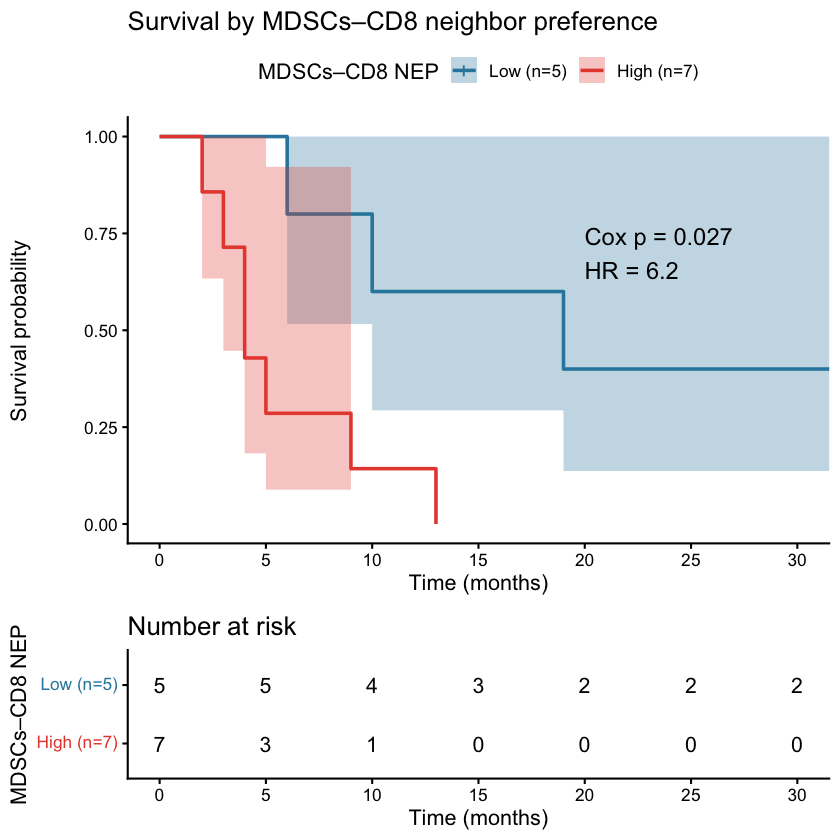

In [15]:
# ---- thresholds (pre-specified, biologically motivated) ----
DIFF_MIN   <- 1     # MDSC->CD8 must exceed CD8->MDSC by at least this
REQUIRE_POS <- TRUE # MDSC->CD8 enrichment must itself be positive

# ---- build per-patient interaction table, keep BOTH directions ----
mdscs_interaction_cd8 <- interaction_df %>%
  filter(cell_pair %in% c("MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs")) %>%
  select(patient_ID, cell_pair, zscore) %>%
  pivot_wider(names_from = cell_pair, values_from = zscore) %>%
  mutate(
    mdsc_to_cd8 = `MDSCs-CD8+ T cells`,       # suppressive direction
    cd8_to_mdsc = `CD8+ T cells-MDSCs`,
    zscore_diff = mdsc_to_cd8 - cd8_to_mdsc   # directional asymmetry
  ) %>%
  left_join(survival_df, by = "patient_ID") %>%
  select(patient_ID, mdsc_to_cd8, cd8_to_mdsc, zscore_diff,
         survival_time_months, event, is_lung)

# ---- prep + define High/Low by the pre-specified rule ----
model_df <- mdscs_interaction_cd8 %>%
  filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
  mutate(
    is_high = (zscore_diff >= DIFF_MIN) & (!REQUIRE_POS | mdsc_to_cd8 > 0),
    MDSCs_group = factor(ifelse(is_high, "High", "Low"), levels = c("Low", "High"))
  )

cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")
model_df %>% count(MDSCs_group) %>% print()
model_df %>% select(patient_ID, mdsc_to_cd8, cd8_to_mdsc, zscore_diff, MDSCs_group) %>%
  arrange(desc(zscore_diff)) %>% print()

fit_cox <- coxph(
  Surv(survival_time_months, event) ~ MDSCs_group,
  data = model_df
)
print(summary(fit_cox))
print(cox.zph(fit_cox))

cox_p  <- summary(fit_cox)$coefficients["MDSCs_groupHigh", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["MDSCs_groupHigh", "exp(coef)"]

# =====================================================================
# KM on the pre-specified group
# =====================================================================
fit_km <- survfit(Surv(survival_time_months, event) ~ MDSCs_group, data = model_df)

n_high <- sum(model_df$MDSCs_group == "High")
n_low  <- sum(model_df$MDSCs_group == "Low")

km <- ggsurvplot(
  fit_km,
  data        = model_df,
  pval        = paste0("Cox p = ", signif(cox_p, 2),
                       "\nHR = ", signif(cox_hr, 2)),
  pval.coord  = c(20, 0.7),
  conf.int    = TRUE,
  risk.table  = TRUE,
  risk.table.height = 0.28,
  palette     = c("#2E86AB", "#E74C3C"),
  xlab        = "Time (months)",
  ylab        = "Survival probability",
  title       = "Survival by MDSCs\u2013CD8 neighbor preference",
  legend.title = "MDSCs\u2013CD8 NEP",
  legend.labs  = c(paste0("Low (n=", n_low, ")"),
                   paste0("High (n=", n_high, ")")),
    xlim        = c(0, 30),          # zoom to where events happen
  break.time.by = 5,              # ticks every 10 months
  ggtheme     = theme_classic(base_size = 13)
)
km

ggsave(file.path(results_dir, "KM_MDSC_CD8_prespecified_split.pdf"),
       plot = km$plot, width = 7, height = 5, dpi = 300, bg = "white")
ggsave(file.path(results_dir, "KM_MDSC_CD8_prespecified_split_table.pdf"),
       plot = km$table, width = 7, height = 2, dpi = 300, bg = "white")

n = 12  events = 11 
# A tibble: 2 × 2
  MDSCs_group     n
  <fct>       <int>
1 Low             7
2 High            5
# A tibble: 12 × 5
   patient_ID mdsc_to_cd4 cd4_to_mdsc zscore_diff MDSCs_group
   <chr>            <dbl>       <dbl>       <dbl> <fct>      
 1 NUT_9          16.5         0.313      16.2    High       
 2 NUT_16         18.6         4.82       13.8    High       
 3 NUT_4           4.00       -0.370       4.37   High       
 4 NUT_7          -8.68      -11.3         2.66   Low        
 5 NUT_5           6.71        5.06        1.65   High       
 6 NUT_15          1.56       -0.0544      1.62   High       
 7 NUT_1           0.0398     -0.0298      0.0696 Low        
 8 NUT_12         -0.105       0.176      -0.281  Low        
 9 NUT_13          0.401       0.932      -0.532  Low        
10 NUT_14          7.44        8.53       -1.10   Low        
11 NUT_2           3.29        8.25       -4.95   Low        
12 NUT_8           1.47        7.13       -5.66   Low   

Ignoring unknown labels:
• colour : "MDSCs–CD4 NEP"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'MDSCs–CD4 NEP' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Survival by MDSCs–CD4 neighbor preference' in 'mbcsToSbcs': - substituted for – (U+2013)”
Ignoring unknown labels:
• colour : "MDSCs–CD4 NEP"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'MDSCs–CD4 NEP' in 'mbcsToSbcs': - substituted for – (U+2013)”


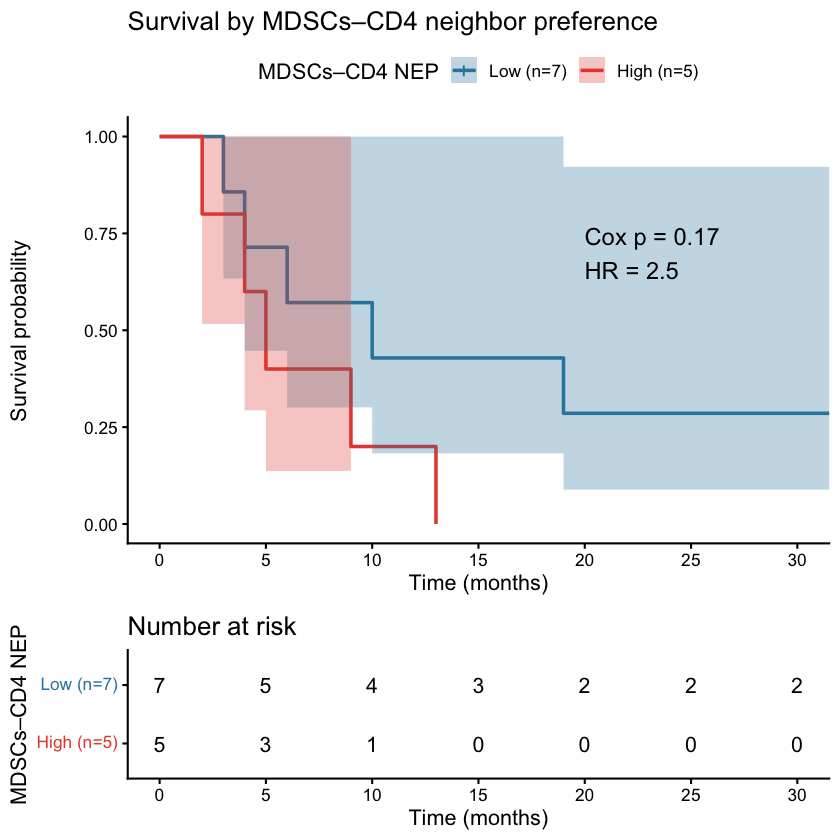

In [16]:
# ---- thresholds (pre-specified, biologically motivated) ----
DIFF_MIN   <- 1     # MDSC->CD8 must exceed CD8->MDSC by at least this
REQUIRE_POS <- TRUE # MDSC->CD8 enrichment must itself be positive

# ---- build per-patient interaction table, keep BOTH directions ----
mdscs_interaction_cd4 <- interaction_df %>%
  filter(cell_pair %in% c("MDSCs-CD4+ T cells", "CD4+ T cells-MDSCs")) %>%
  select(patient_ID, cell_pair, zscore) %>%
  pivot_wider(names_from = cell_pair, values_from = zscore) %>%
  mutate(
    mdsc_to_cd4 = `MDSCs-CD4+ T cells`,       # suppressive direction
    cd4_to_mdsc = `CD4+ T cells-MDSCs`,
    zscore_diff = mdsc_to_cd4 - cd4_to_mdsc   # directional asymmetry
  ) %>%
  left_join(survival_df, by = "patient_ID") %>%
  select(patient_ID, mdsc_to_cd4, cd4_to_mdsc, zscore_diff,
         survival_time_months, event, is_lung)

# ---- prep + define High/Low by the pre-specified rule ----
model_df <- mdscs_interaction_cd4 %>%
  filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
  mutate(
    is_high = (zscore_diff >= DIFF_MIN) & (!REQUIRE_POS | mdsc_to_cd4 > 0),
    MDSCs_group = factor(ifelse(is_high, "High", "Low"), levels = c("Low", "High"))
  )

cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")
model_df %>% count(MDSCs_group) %>% print()
model_df %>% select(patient_ID, mdsc_to_cd4, cd4_to_mdsc, zscore_diff, MDSCs_group) %>%
  arrange(desc(zscore_diff)) %>% print()

# =====================================================================
# Cox on the BINARY group (single covariate, no stratification)
# =====================================================================
fit_cox <- coxph(
  Surv(survival_time_months, event) ~ MDSCs_group,
  data = model_df
)
print(summary(fit_cox))
print(cox.zph(fit_cox))

cox_p  <- summary(fit_cox)$coefficients["MDSCs_groupHigh", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["MDSCs_groupHigh", "exp(coef)"]

# =====================================================================
# KM on the pre-specified group
# =====================================================================
fit_km <- survfit(Surv(survival_time_months, event) ~ MDSCs_group, data = model_df)

n_high <- sum(model_df$MDSCs_group == "High")
n_low  <- sum(model_df$MDSCs_group == "Low")

km <- ggsurvplot(
  fit_km,
  data        = model_df,
  pval        = paste0("Cox p = ", signif(cox_p, 2),
                       "\nHR = ", signif(cox_hr, 2)),
  pval.coord  = c(20, 0.7),
  conf.int    = TRUE,
  risk.table  = TRUE,
  risk.table.height = 0.28,
  palette     = c("#2E86AB", "#E74C3C"),
  xlab        = "Time (months)",
  ylab        = "Survival probability",
  title       = "Survival by MDSCs\u2013CD4 neighbor preference",
  legend.title = "MDSCs\u2013CD4 NEP",
  legend.labs  = c(paste0("Low (n=", n_low, ")"),
                   paste0("High (n=", n_high, ")")),
    xlim        = c(0, 30),          # zoom to where events happen
  break.time.by = 5,              # ticks every 10 months
  ggtheme     = theme_classic(base_size = 13)
)
km

ggsave(file.path(results_dir, "KM_MDSC_CD4_prespecified_split.pdf"),
       plot = km$plot, width = 7, height = 5, dpi = 300, bg = "white")
ggsave(file.path(results_dir, "KM_MDSC_CD4_prespecified_split_table.pdf"),
       plot = km$table, width = 7, height = 2, dpi = 300, bg = "white")

n = 13  events = 12 
# A tibble: 2 × 2
  M2_group     n
  <fct>    <int>
1 Low          9
2 High         4
# A tibble: 13 × 5
   patient_ID m2_to_cd4 cd4_to_m2 zscore_diff M2_group
   <chr>          <dbl>     <dbl>       <dbl> <fct>   
 1 NUT_16         9.50      2.06        7.45  High    
 2 NUT_9         19.1      11.8         7.31  High    
 3 NUT_7         11.1       4.96        6.10  High    
 4 NUT_12         5.99      0.789       5.20  High    
 5 NUT_14         6.34      5.76        0.575 Low     
 6 NUT_13         0.579     1.22       -0.639 Low     
 7 NUT_15         0.225     1.31       -1.09  Low     
 8 NUT_1          1.46      3.00       -1.54  Low     
 9 NUT_5          6.17     10.9        -4.76  Low     
10 NUT_6          4.27     11.5        -7.27  Low     
11 NUT_4          1.54      9.19       -7.65  Low     
12 NUT_2          3.61     13.1        -9.51  Low     
13 NUT_8         -0.602    10.1       -10.7   Low     
Call:
coxph(formula = Surv(survival_time_months, 

Ignoring unknown labels:
• colour : "M2-like macrophages–CD4 NEP"
Ignoring unknown labels:
• colour : "M2-like macrophages–CD4 NEP"


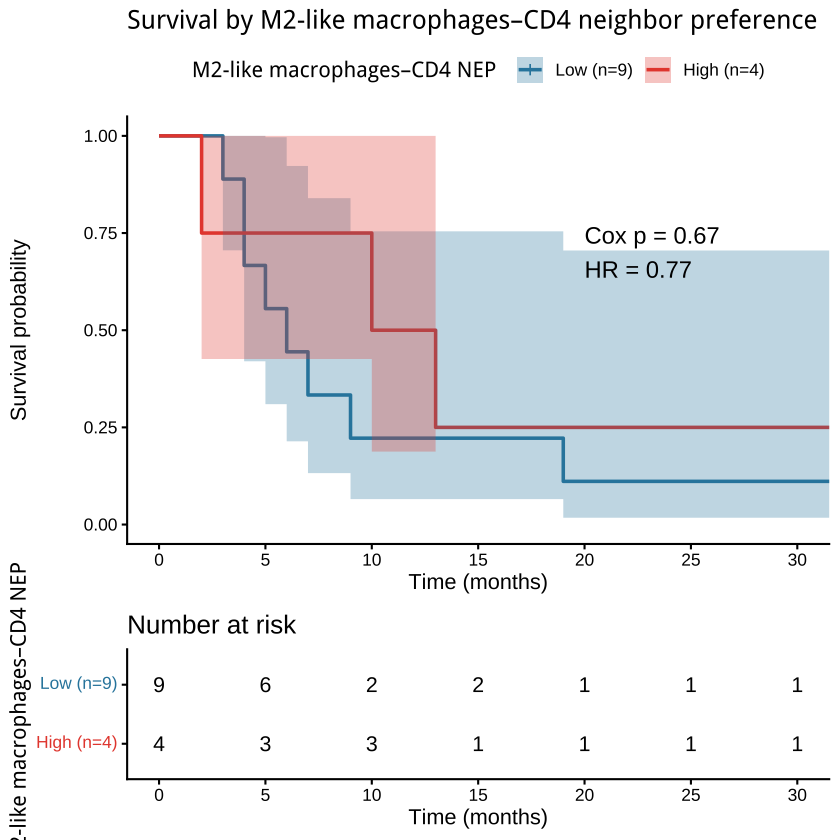

In [26]:
# ---- thresholds (pre-specified, biologically motivated) ----
DIFF_MIN   <- 1     # MDSC->CD8 must exceed CD8->MDSC by at least this
REQUIRE_POS <- TRUE # MDSC->CD8 enrichment must itself be positive

# ---- build per-patient interaction table, keep BOTH directions ----
m2_mac_interaction_cd4 <- interaction_df %>%
  filter(cell_pair %in% c("M2 macrophages-CD4+ T cells", "CD4+ T cells-M2 macrophages")) %>%
  select(patient_ID, cell_pair, zscore) %>%
  pivot_wider(names_from = cell_pair, values_from = zscore) %>%
  mutate(
    m2_to_cd4 = `M2 macrophages-CD4+ T cells`,       # suppressive direction
    cd4_to_m2 = `CD4+ T cells-M2 macrophages`,
    zscore_diff = m2_to_cd4 - cd4_to_m2   # directional asymmetry
  ) %>%
  left_join(survival_df, by = "patient_ID") %>%
  select(patient_ID, m2_to_cd4, cd4_to_m2, zscore_diff,
         survival_time_months, event, is_lung)

# ---- prep + define High/Low by the pre-specified rule ----
model_df <- m2_mac_interaction_cd4 %>%
  filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
  mutate(
    is_high = (zscore_diff >= DIFF_MIN) & (!REQUIRE_POS | m2_to_cd4 > 0),
    M2_group = factor(ifelse(is_high, "High", "Low"), levels = c("Low", "High"))
  )

cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")
model_df %>% count(M2_group) %>% print()
model_df %>% select(patient_ID, m2_to_cd4, cd4_to_m2, zscore_diff, M2_group) %>%
  arrange(desc(zscore_diff)) %>% print()

# =====================================================================
# Cox on the BINARY group (single covariate, no stratification)
# =====================================================================
fit_cox <- coxph(
  Surv(survival_time_months, event) ~ M2_group,
  data = model_df
)
print(summary(fit_cox))
print(cox.zph(fit_cox))

cox_p  <- summary(fit_cox)$coefficients["M2_groupHigh", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["M2_groupHigh", "exp(coef)"]

# =====================================================================
# KM on the pre-specified group
# =====================================================================
fit_km <- survfit(Surv(survival_time_months, event) ~ M2_group, data = model_df)

n_high <- sum(model_df$M2_group == "High")
n_low  <- sum(model_df$M2_group == "Low")

km <- ggsurvplot(
  fit_km,
  data        = model_df,
  pval        = paste0("Cox p = ", signif(cox_p, 2),
                       "\nHR = ", signif(cox_hr, 2)),
  pval.coord  = c(20, 0.7),
  conf.int    = TRUE,
  risk.table  = TRUE,
  risk.table.height = 0.28,
  palette     = c("#2E86AB", "#E74C3C"),
  xlab        = "Time (months)",
  ylab        = "Survival probability",
  title       = "Survival by M2-like macrophages\u2013CD4 neighbor preference",
  legend.title = "M2-like macrophages\u2013CD4 NEP",
  legend.labs  = c(paste0("Low (n=", n_low, ")"),
                   paste0("High (n=", n_high, ")")),
    xlim        = c(0, 30),          # zoom to where events happen
  break.time.by = 5,              # ticks every 10 months
  ggtheme     = theme_classic(base_size = 13)
)
km

ggsave(file.path(results_dir, "KM_M2_CD4_prespecified_split.pdf"),
       plot = km$plot, width = 7, height = 5, dpi = 300, bg = "white")
ggsave(file.path(results_dir, "KM_M2_CD4_prespecified_split_table.pdf"),
       plot = km$table, width = 7, height = 2, dpi = 300, bg = "white")

n = 13  events = 12 
# A tibble: 2 × 2
  M2_group     n
  <fct>    <int>
1 Low          9
2 High         4
# A tibble: 13 × 5
   patient_ID m2_to_cd8 cd8_to_m2 zscore_diff M2_group
   <chr>          <dbl>     <dbl>       <dbl> <fct>   
 1 NUT_12        15.1       0.523     14.6    High    
 2 NUT_9         13.8       9.73       4.04   High    
 3 NUT_6          7.19      4.94       2.26   High    
 4 NUT_14         3.53      1.72       1.80   High    
 5 NUT_8         -0.318    -0.713      0.395  Low     
 6 NUT_1          0.748     0.511      0.237  Low     
 7 NUT_15        -0.307    -0.218     -0.0886 Low     
 8 NUT_7          4.68      5.59      -0.914  Low     
 9 NUT_13         0.302     1.68      -1.38   Low     
10 NUT_16         7.07      9.09      -2.02   Low     
11 NUT_4          0.397     6.00      -5.61   Low     
12 NUT_5          3.63      9.23      -5.61   Low     
13 NUT_2          0.632    18.5      -17.9    Low     
Call:
coxph(formula = Surv(survival_time_months, 

Ignoring unknown labels:
• colour : "M2-like macrophages–CD8 NEP"
Ignoring unknown labels:
• colour : "M2-like macrophages–CD8 NEP"


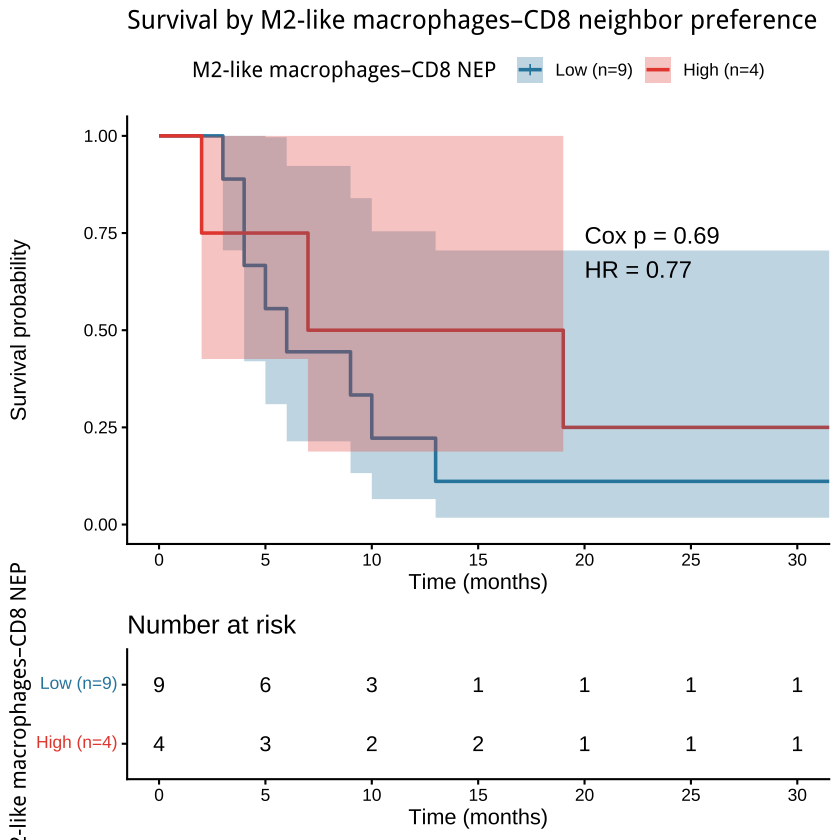

In [27]:
# ---- thresholds (pre-specified, biologically motivated) ----
DIFF_MIN   <- 1     # MDSC->CD8 must exceed CD8->MDSC by at least this
REQUIRE_POS <- TRUE # MDSC->CD8 enrichment must itself be positive

# ---- build per-patient interaction table, keep BOTH directions ----
m2_mac_interaction_cd4 <- interaction_df %>%
  filter(cell_pair %in% c("M2 macrophages-CD8+ T cells", "CD8+ T cells-M2 macrophages")) %>%
  select(patient_ID, cell_pair, zscore) %>%
  pivot_wider(names_from = cell_pair, values_from = zscore) %>%
  mutate(
    m2_to_cd8 = `M2 macrophages-CD8+ T cells`,       # suppressive direction
    cd8_to_m2 = `CD8+ T cells-M2 macrophages`,
    zscore_diff = m2_to_cd8 - cd8_to_m2   # directional asymmetry
  ) %>%
  left_join(survival_df, by = "patient_ID") %>%
  select(patient_ID, m2_to_cd8, cd8_to_m2, zscore_diff,
         survival_time_months, event, is_lung)

# ---- prep + define High/Low by the pre-specified rule ----
model_df <- m2_mac_interaction_cd4 %>%
  filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
  mutate(
    is_high = (zscore_diff >= DIFF_MIN) & (!REQUIRE_POS | m2_to_cd8 > 0),
    M2_group = factor(ifelse(is_high, "High", "Low"), levels = c("Low", "High"))
  )

cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")
model_df %>% count(M2_group) %>% print()
model_df %>% select(patient_ID, m2_to_cd8, cd8_to_m2, zscore_diff, M2_group) %>%
  arrange(desc(zscore_diff)) %>% print()

# =====================================================================
# Cox on the BINARY group (single covariate, no stratification)
# =====================================================================
fit_cox <- coxph(
  Surv(survival_time_months, event) ~ M2_group,
  data = model_df
)
print(summary(fit_cox))
print(cox.zph(fit_cox))

cox_p  <- summary(fit_cox)$coefficients["M2_groupHigh", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["M2_groupHigh", "exp(coef)"]

# =====================================================================
# KM on the pre-specified group
# =====================================================================
fit_km <- survfit(Surv(survival_time_months, event) ~ M2_group, data = model_df)

n_high <- sum(model_df$M2_group == "High")
n_low  <- sum(model_df$M2_group == "Low")

km <- ggsurvplot(
  fit_km,
  data        = model_df,
  pval        = paste0("Cox p = ", signif(cox_p, 2),
                       "\nHR = ", signif(cox_hr, 2)),
  pval.coord  = c(20, 0.7),
  conf.int    = TRUE,
  risk.table  = TRUE,
  risk.table.height = 0.28,
  palette     = c("#2E86AB", "#E74C3C"),
  xlab        = "Time (months)",
  ylab        = "Survival probability",
  title       = "Survival by M2-like macrophages\u2013CD8 neighbor preference",
  legend.title = "M2-like macrophages\u2013CD8 NEP",
  legend.labs  = c(paste0("Low (n=", n_low, ")"),
                   paste0("High (n=", n_high, ")")),
    xlim        = c(0, 30),          # zoom to where events happen
  break.time.by = 5,              # ticks every 10 months
  ggtheme     = theme_classic(base_size = 13)
)
km

ggsave(file.path(results_dir, "KM_M2_CD8_prespecified_split.pdf"),
       plot = km$plot, width = 7, height = 5, dpi = 300, bg = "white")
ggsave(file.path(results_dir, "KM_M2_CD8_prespecified_split_table.pdf"),
       plot = km$table, width = 7, height = 2, dpi = 300, bg = "white")

# A tibble: 4 × 3
  cell_pair          surv_group            n
  <fct>              <fct>             <int>
1 MDSCs-CD8+ T cells Below site median     4
2 MDSCs-CD8+ T cells Above site median     8
3 MDSCs-CD4+ T cells Below site median     4
4 MDSCs-CD4+ T cells Above site median     8


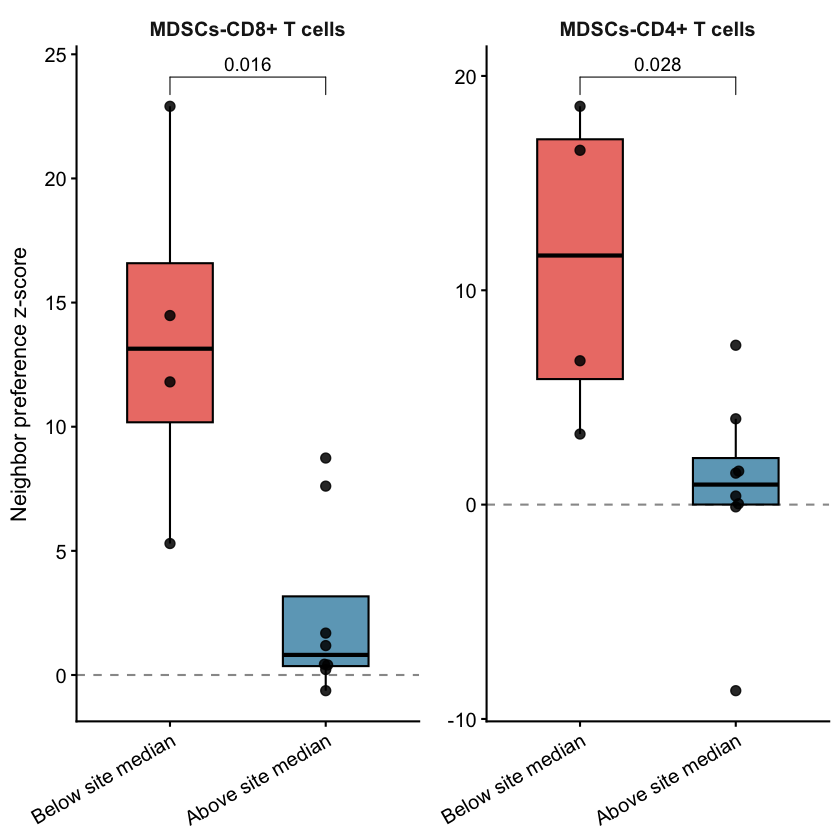

In [19]:
library(dplyr); library(tidyr); library(ggplot2); library(ggbeeswarm); library(ggpubr)

# --- classify each patient relative to the median survival of THEIR site group ---
surv_class <- survival_df %>%
  mutate(patient_ID = as.character(patient_ID)) %>%
  filter(patient_ID != "NUT_6") %>%              # MDSC NEP not computable
  group_by(is_lung) %>%
  mutate(site_median = median(survival_time_months, na.rm = TRUE),
         surv_group  = ifelse(survival_time_months < site_median,
                              "Below site median", "Above site median")) %>%
  ungroup() %>%
  mutate(surv_group = factor(surv_group,
                             levels = c("Below site median", "Above site median")))

mdsc_pairs <- c("MDSCs-CD8+ T cells", "MDSCs-CD4+ T cells")

plot_df <- interaction_df %>%
  mutate(patient_ID = as.character(patient_ID)) %>%
  filter(cell_pair %in% mdsc_pairs, patient_ID != "NUT_6", !is.na(zscore)) %>%
  inner_join(surv_class, by = "patient_ID") %>%
  mutate(cell_pair = factor(cell_pair, levels = mdsc_pairs))

plot_df %>% count(cell_pair, surv_group) %>% as_tibble() %>% print(n = Inf)

grp_cols <- c("Below site median" = "#E74C3C", "Above site median" = "#2E86AB")

p <- ggplot(plot_df, aes(x = surv_group, y = zscore, fill = surv_group)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey60") +
  geom_boxplot(width = 0.55, alpha = 0.75, colour = "black", outlier.shape = NA) +
  geom_beeswarm(size = 2.4, alpha = 0.85, colour = "black") +
  stat_compare_means(method = "wilcox.test", label = "p.format",
                     comparisons = list(c("Below site median", "Above site median")),
                     size = 4) +
  facet_wrap(~ cell_pair, nrow = 1, scales = "free_y") +
  scale_fill_manual(values = grp_cols, guide = "none") +
  labs(x = NULL, y = "Neighbor preference z-score") +
  theme_classic(base_family = "Arial", base_size = 13) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 12, colour = "black"),
        axis.text.y = element_text(size = 12, colour = "black"),
        axis.title.y = element_text(size = 13, colour = "black", margin = margin(r = 8)),
        strip.background = element_blank(),
        strip.text = element_text(size = 12, face = "bold"),
        panel.spacing = unit(1.2, "lines"))
p

ggsave(file.path(results_dir, "MDSC_NEP_by_site_median_survival.pdf"),
       p, width = 7, height = 4.5, dpi = 300, bg = "white", device = cairo_pdf)